In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path

REPO = Path("/home/huy/quan_nguyen/aima/pancrea_cyst")
TEST_TXT = REPO / "data" / "test.txt"
FAILURE_CSV = REPO / "results" / "analysis" / "universal_failure_cases.csv"
SUCCESS_CSV = REPO / "results" / "analysis" / "top5_successful_cases.csv"

APPROACH_PRED_DIRS = {
    "A-3D": REPO / "approach_a" / "prediction" / "3d_fullres",
    "A-2.5D": REPO / "approach_a" / "prediction" / "2d_stack5",
    "B": REPO / "approach_b" / "predictio" / "full_space",
    "D": REPO / "approach_d" / "prediction",
}

AXES = {"Axial": 2, "Coronal": 1, "Sagittal": 0}

# Build case map from data/test.txt
case_map = {}
for line in TEST_TXT.read_text().splitlines()[1:]:
    line = line.strip()
    if not line:
        continue
    image_path, mask_path = line.split(",")[:2]
    case = Path(image_path).name.replace(".nii.gz", "")
    case_map[case] = (Path(image_path), Path(mask_path))

if FAILURE_CSV.exists():
    failed_cases_df = pd.read_csv(FAILURE_CSV)
    failure_cases = failed_cases_df["case"].tolist()
else:
    failed_cases_df = pd.DataFrame()
    failure_cases = ["NU63", "NYU0076", "EMC077", "NYU0165", "IU59"]

if SUCCESS_CSV.exists():
    success_cases_df = pd.read_csv(SUCCESS_CSV)
    success_cases = success_cases_df["case"].tolist()
else:
    success_cases_df = pd.DataFrame()
    success_cases = ["CAD262", "IU66", "NYU0058", "NYU0064", "CAD239"]

failure_cases = [case for case in failure_cases if case in case_map]
success_cases = [case for case in success_cases if case in case_map]
all_visual_cases = list(dict.fromkeys(failure_cases + success_cases))

CASE_GROUPS = {
    "Universal failures": failure_cases,
    "Top 5 successes": success_cases,
    "All selected": all_visual_cases,
}
valid_cases = all_visual_cases

print(f"Found {len(case_map)} test cases")
print(f"Universal-failure cases: {failure_cases}")
print(f"Top 5 successful cases: {success_cases}")
print("Prediction folders:")
for name, path in APPROACH_PRED_DIRS.items():
    print(f"  {name}: {path}")


Found 74 test cases
Universal-failure cases: ['NU63', 'NYU0076', 'EMC077', 'NYU0165', 'IU59']
Top 5 successful cases: ['CAD262', 'IU66', 'NYU0058', 'NYU0064', 'CAD239']
Prediction folders:
  A-3D: /home/huy/quan_nguyen/aima/pancrea_cyst/approach_a/prediction/3d_fullres
  A-2.5D: /home/huy/quan_nguyen/aima/pancrea_cyst/approach_a/prediction/2d_stack5
  B: /home/huy/quan_nguyen/aima/pancrea_cyst/approach_b/predictio/full_space
  D: /home/huy/quan_nguyen/aima/pancrea_cyst/approach_d/prediction


In [8]:
# Cache loaded volumes so switching cases/slices is instant.
# Cache key includes approach because the predictions differ by model.
_cache = {}


def load_case(case, approach="A-3D"):
    key = (approach, case)
    if key in _cache:
        return _cache[key]

    img_path, mask_path = case_map[case]
    pred_path = APPROACH_PRED_DIRS[approach] / f"{case}.nii.gz"

    img = nib.load(str(img_path)).get_fdata()
    mask = nib.load(str(mask_path)).get_fdata()
    pred = nib.load(str(pred_path)).get_fdata() if pred_path.exists() else np.zeros_like(mask)

    if img.shape != mask.shape or img.shape != pred.shape:
        raise ValueError(
            f"Shape mismatch for {case} / {approach}: "
            f"image={img.shape}, mask={mask.shape}, pred={pred.shape}"
        )

    _cache[key] = (img, mask, pred, img_path, mask_path, pred_path)
    return _cache[key]


def dice(pred, mask):
    p, g = pred > 0, mask > 0
    denom = int(p.sum() + g.sum())
    return float(2 * int((p & g).sum()) / denom) if denom else 1.0


def precision(pred, mask):
    p, g = pred > 0, mask > 0
    tp = int((p & g).sum())
    fp = int((p & ~g).sum())
    return float(tp / (tp + fp)) if (tp + fp) else 0.0


def recall(pred, mask):
    p, g = pred > 0, mask > 0
    tp = int((p & g).sum())
    fn = int((~p & g).sum())
    return float(tp / (tp + fn)) if (tp + fn) else 0.0


def best_slice(mask, axis):
    if mask.max() <= 0:
        return mask.shape[axis] // 2
    reduce_axes = tuple(i for i in range(mask.ndim) if i != axis)
    return int(np.argmax(mask.sum(axis=reduce_axes)))


def get_slice(arr, axis, slice_idx):
    if axis == 0:
        sl = arr[slice_idx, :, :]
    elif axis == 1:
        sl = arr[:, slice_idx, :]
    else:
        sl = arr[:, :, slice_idx]
    return np.rot90(sl)


def overlay_panel(ax, img_sl, mask_sl, pred_sl=None, title="", vmin=None, vmax=None, show_contour=True):
    ax.imshow(img_sl, cmap="gray", vmin=vmin, vmax=vmax)
    if mask_sl is not None and mask_sl.max() > 0:
        ax.imshow(mask_sl, cmap="Reds", alpha=0.35)
        if show_contour:
            ax.contour(mask_sl, colors="yellow", linewidths=1)
    if pred_sl is not None and pred_sl.max() > 0:
        ax.imshow(pred_sl, cmap="Greens", alpha=0.35)
        if show_contour:
            ax.contour(pred_sl, colors="lime", linewidths=1)
    ax.set_title(title, color="white", fontsize=11)
    ax.axis("off")
    ax.set_facecolor("black")

print("Helpers ready.")


Helpers ready.


In [9]:
# Interactive viewer for failed and successful cases.
# Use Case group to switch between universal failures and top 5 successes.
# Use Approach to switch among A-3D, A-2.5D, B, and D.
import ipywidgets as widgets
from IPython.display import display

case_group_dd = widgets.Dropdown(options=list(CASE_GROUPS), value="Universal failures", description="Group")
case_dd = widgets.Dropdown(options=CASE_GROUPS[case_group_dd.value], value=CASE_GROUPS[case_group_dd.value][0], description="Case")
approach_dd = widgets.Dropdown(options=list(APPROACH_PRED_DIRS), value="A-3D", description="Approach")
view_dd = widgets.Dropdown(options=list(AXES), value="Axial", description="View")
slice_sl = widgets.IntSlider(
    min=0, max=1, step=1, value=0,
    description="Slice", continuous_update=False,
    layout=widgets.Layout(width="60%"),
)
vmin_sl = widgets.FloatSlider(min=0, max=50, step=0.5, value=1, description="vmin %", continuous_update=False)
vmax_sl = widgets.FloatSlider(min=50, max=100, step=0.5, value=99, description="vmax %", continuous_update=False)
contour_cb = widgets.Checkbox(value=True, description="Contour")


def _update_slice_limits(*_):
    img, mask, pred, *_ = load_case(case_dd.value, approach_dd.value)
    axis = AXES[view_dd.value]
    slice_sl.max = img.shape[axis] - 1
    slice_sl.value = best_slice(mask, axis)


def _on_group_change(*_):
    cases = CASE_GROUPS[case_group_dd.value]
    case_dd.options = cases
    case_dd.value = cases[0]
    _update_slice_limits()


case_group_dd.observe(_on_group_change, names="value")
case_dd.observe(_update_slice_limits, names="value")
approach_dd.observe(_update_slice_limits, names="value")
view_dd.observe(_update_slice_limits, names="value")


def plot_slice(case, approach, view, slice_idx, vmin_pct, vmax_pct, show_contour):
    img, mask, pred, img_path, mask_path, pred_path = load_case(case, approach)
    axis = AXES[view]
    slice_idx = min(slice_idx, img.shape[axis] - 1)

    vmin = float(np.percentile(img, vmin_pct))
    vmax = float(np.percentile(img, vmax_pct))

    img_sl = get_slice(img, axis, slice_idx)
    mask_sl = (get_slice(mask, axis, slice_idx) > 0).astype(np.uint8)
    pred_sl = (get_slice(pred, axis, slice_idx) > 0).astype(np.uint8)

    dc = dice(pred, mask)
    pr = precision(pred, mask)
    rc = recall(pred, mask)
    gt_vox = int((mask > 0).sum())
    pred_vox = int((pred > 0).sum())

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("#111")
    overlay_panel(axes[0], img_sl, None, None, f"MRI - {view} {slice_idx}", vmin, vmax, show_contour)
    overlay_panel(axes[1], img_sl, mask_sl, None, "Ground truth", vmin, vmax, show_contour)
    overlay_panel(axes[2], img_sl, mask_sl, pred_sl, "GT red/yellow vs Pred green", vmin, vmax, show_contour)

    fig.suptitle(
        f"{case_group_dd.value} | {approach} | {case} | GT: {gt_vox} vox | Pred: {pred_vox} vox | "
        f"Dice/F1: {dc:.4f} | Precision: {pr:.4f} | Recall: {rc:.4f}"
        + (" | pred=0" if pred_vox == 0 and gt_vox > 0 else ""),
        color="#ddd", fontsize=11,
    )
    plt.tight_layout()
    plt.show()


out = widgets.interactive_output(
    plot_slice,
    dict(
        case=case_dd,
        approach=approach_dd,
        view=view_dd,
        slice_idx=slice_sl,
        vmin_pct=vmin_sl,
        vmax_pct=vmax_sl,
        show_contour=contour_cb,
    ),
)

_update_slice_limits()

display(
    widgets.VBox([
        widgets.HBox([case_group_dd, case_dd, approach_dd, view_dd]),
        slice_sl,
        widgets.HBox([vmin_sl, vmax_sl, contour_cb]),
    ]),
    out,
)


Output()

In [10]:
# Metric table for failed and top-success cases by approach.
print(f"{'Group':<19} {'Case':<10} {'Approach':<8} {'Shape':>15} {'GT vox':>8} {'Pred vox':>9} {'Dice':>7} {'Prec':>7} {'Recall':>7} {'Best z':>6}")
print("-" * 112)
for group_name, cases in CASE_GROUPS.items():
    if group_name == "All selected":
        continue
    for case in cases:
        for approach in APPROACH_PRED_DIRS:
            img, mask, pred, *_ = load_case(case, approach)
            bz = best_slice(mask, axis=2)
            gt_vox = int((mask > 0).sum())
            pred_vox = int((pred > 0).sum())
            flag = " pred=0" if pred_vox == 0 and gt_vox > 0 else ""
            print(
                f"{group_name:<19} {case:<10} {approach:<8} {str(img.shape):>15} {gt_vox:>8} {pred_vox:>9} "
                f"{dice(pred, mask):>7.4f} {precision(pred, mask):>7.4f} {recall(pred, mask):>7.4f} {bz:>6}{flag}"
            )
        print()


Group               Case       Approach           Shape   GT vox  Pred vox    Dice    Prec  Recall Best z
----------------------------------------------------------------------------------------------------------------
Universal failures  NU63       A-3D      (320, 250, 44)       10        89  0.0000  0.0000  0.0000     26
Universal failures  NU63       A-2.5D    (320, 250, 44)       10        82  0.0000  0.0000  0.0000     26
Universal failures  NU63       B         (320, 250, 44)       10       108  0.0000  0.0000  0.0000     26
Universal failures  NU63       D         (320, 250, 44)       10       121  0.0000  0.0000  0.0000     26

Universal failures  NYU0076    A-3D      (320, 270, 40)       16       302  0.0000  0.0000  0.0000     23
Universal failures  NYU0076    A-2.5D    (320, 270, 40)       16       215  0.0000  0.0000  0.0000     23
Universal failures  NYU0076    B         (320, 270, 40)       16        64  0.0000  0.0000  0.0000     23
Universal failures  NYU0076    D      

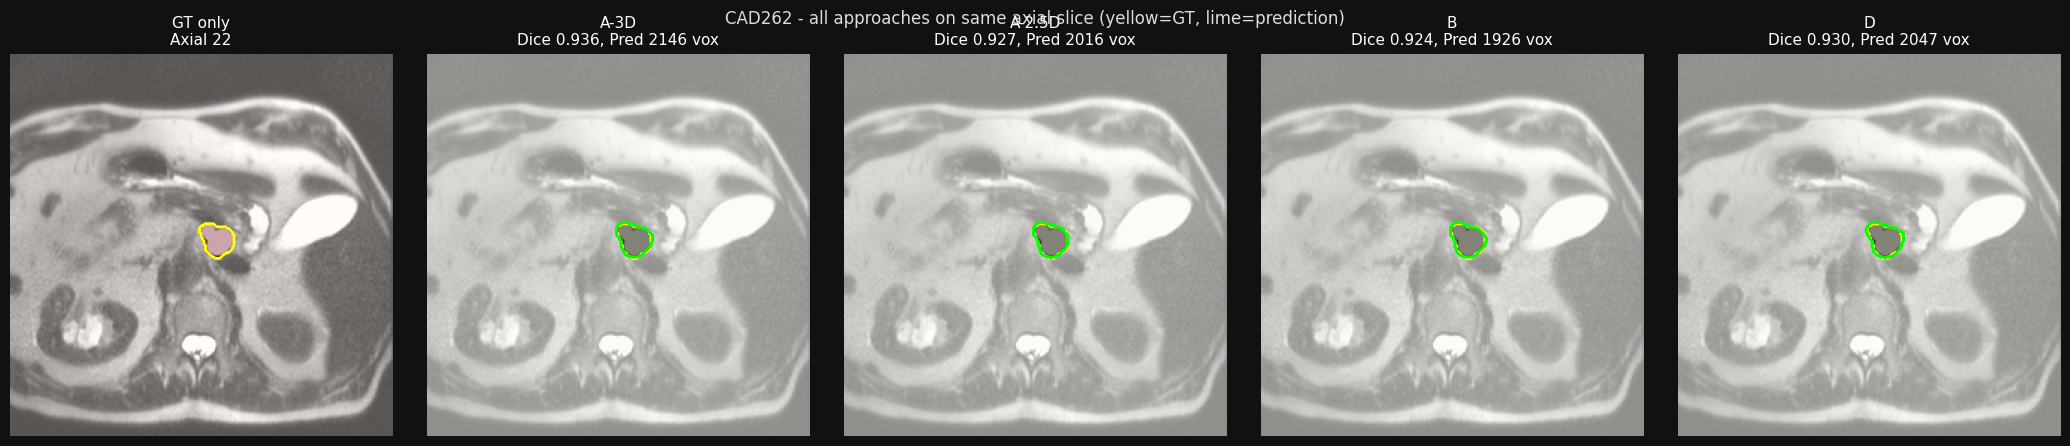

In [11]:
# Compare all approaches for one case on the same slice.
# Try failure cases such as IU59, or top-success cases such as CAD262.
COMPARE_CASE = success_cases[0] if success_cases else "CAD262"
COMPARE_VIEW = "Axial"     # Axial, Coronal, Sagittal
COMPARE_SLICE = None       # None uses the best GT slice; or set an integer

img0, mask0, _, *_ = load_case(COMPARE_CASE, "A-3D")
axis = AXES[COMPARE_VIEW]
slice_idx = best_slice(mask0, axis) if COMPARE_SLICE is None else int(COMPARE_SLICE)
p1, p99 = float(np.percentile(img0, 1)), float(np.percentile(img0, 99))

fig, axes = plt.subplots(1, 1 + len(APPROACH_PRED_DIRS), figsize=(4.2 * (1 + len(APPROACH_PRED_DIRS)), 4.5))
fig.patch.set_facecolor("#111")

img_sl = get_slice(img0, axis, slice_idx)
mask_sl = (get_slice(mask0, axis, slice_idx) > 0).astype(np.uint8)
overlay_panel(axes[0], img_sl, mask_sl, None, f"GT only\n{COMPARE_VIEW} {slice_idx}", p1, p99)

for ax, approach in zip(axes[1:], APPROACH_PRED_DIRS):
    img, mask, pred, *_ = load_case(COMPARE_CASE, approach)
    pred_sl = (get_slice(pred, axis, slice_idx) > 0).astype(np.uint8)
    title = (
        f"{approach}\n"
        f"Dice {dice(pred, mask):.3f}, Pred {int((pred > 0).sum())} vox"
    )
    overlay_panel(ax, img_sl, mask_sl, pred_sl, title, p1, p99)

fig.suptitle(
    f"{COMPARE_CASE} - all approaches on same {COMPARE_VIEW.lower()} slice "
    f"(yellow=GT, lime=prediction)",
    color="#ddd", fontsize=12,
)
plt.tight_layout()
plt.show()


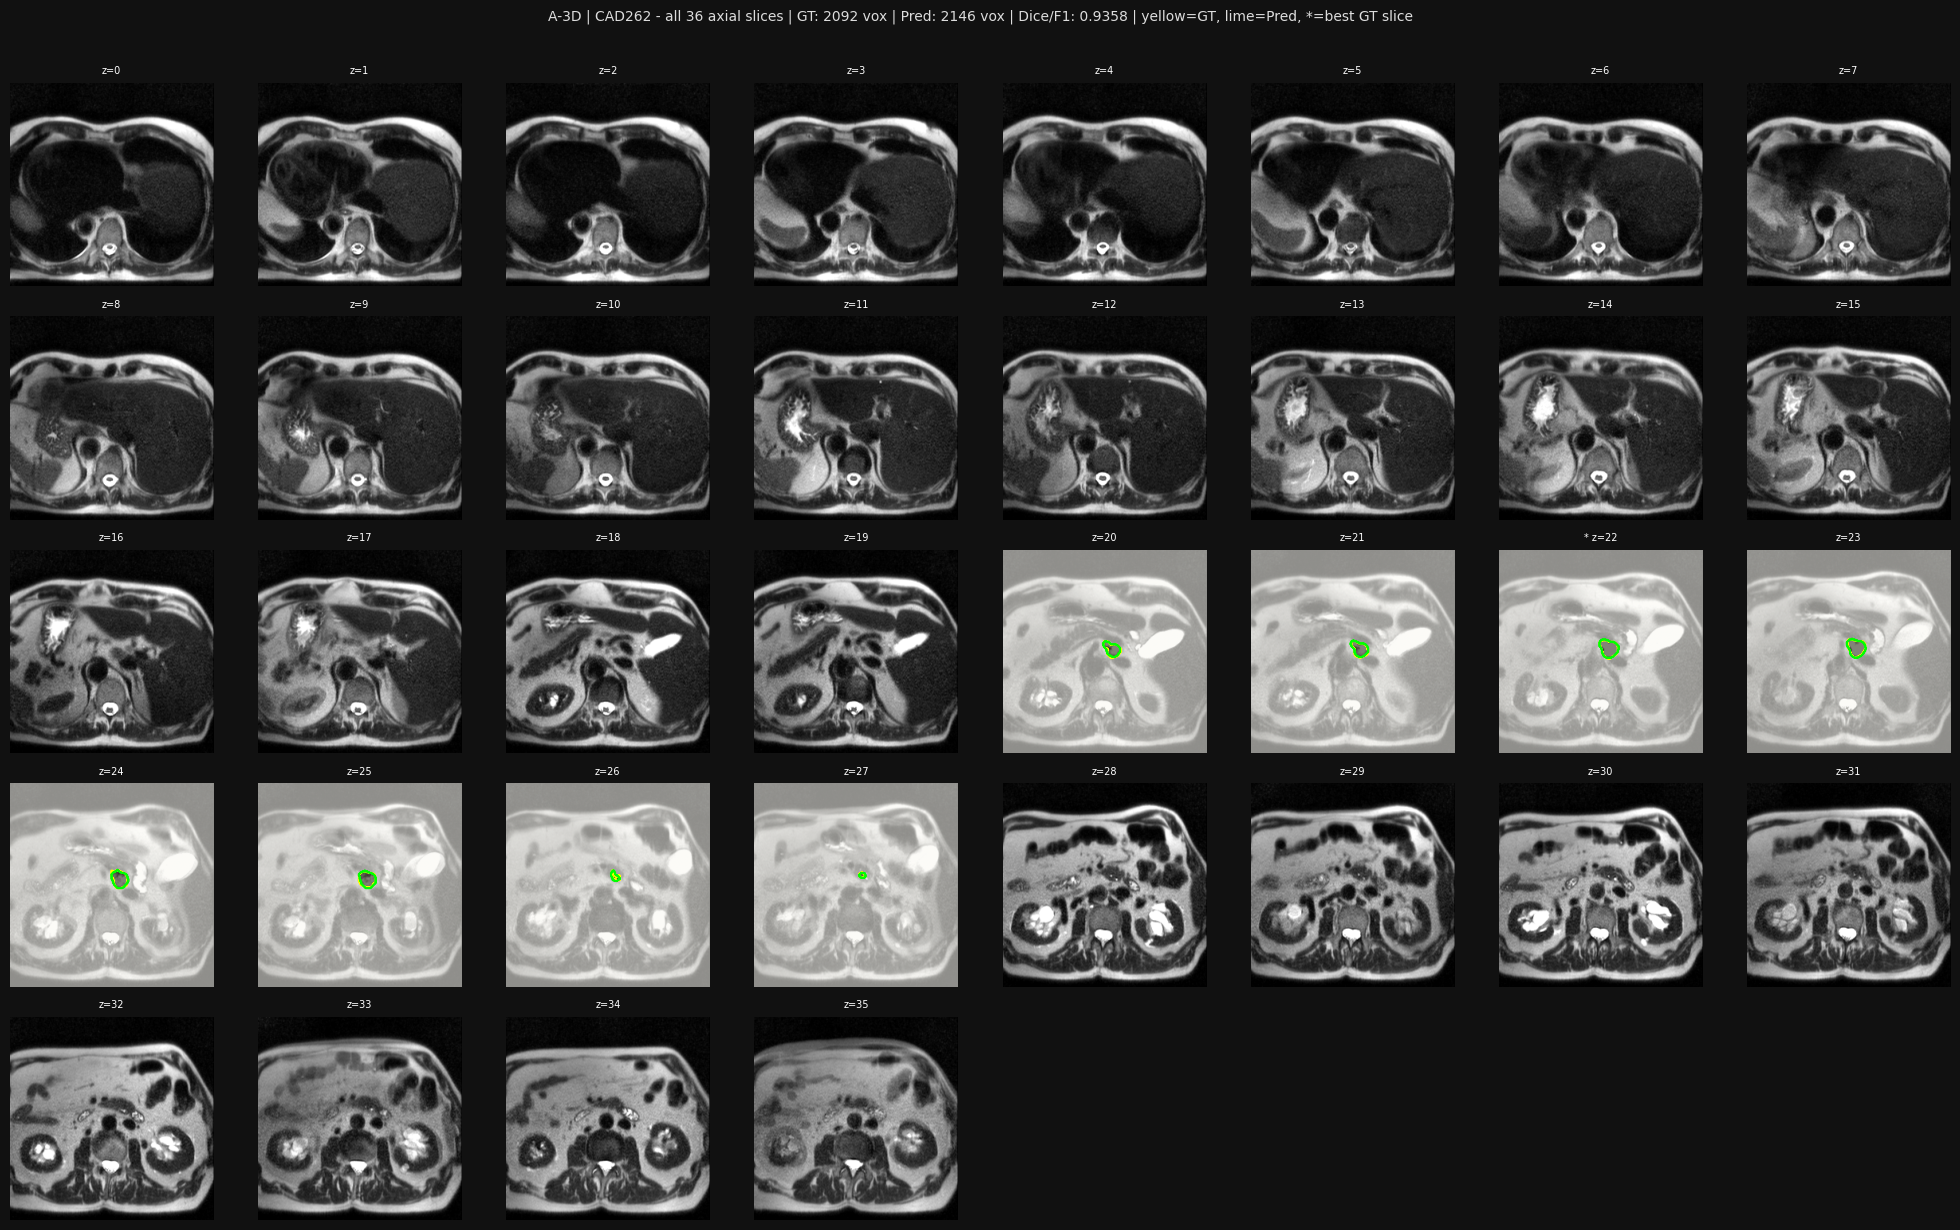

In [12]:
# All-slices grid for one case and one approach.
GRID_CASE = success_cases[0] if success_cases else "CAD262"
GRID_APPROACH = "A-3D" # A-3D, A-2.5D, B, D
GRID_COLS = 8

img, mask, pred, *_ = load_case(GRID_CASE, GRID_APPROACH)
p1, p99 = float(np.percentile(img, 1)), float(np.percentile(img, 99))
n_slices = img.shape[2]  # axial
bz = best_slice(mask, axis=2)
dc = dice(pred, mask)

n_rows = (n_slices + GRID_COLS - 1) // GRID_COLS
fig, axes = plt.subplots(n_rows, GRID_COLS, figsize=(GRID_COLS * 2.5, n_rows * 2.5))
fig.patch.set_facecolor("#111")
axes = np.array(axes).reshape(-1)

for z in range(n_slices):
    ax = axes[z]
    sl_img = np.rot90(img[:, :, z])
    sl_mask = (np.rot90(mask[:, :, z]) > 0).astype(np.uint8)
    sl_pred = (np.rot90(pred[:, :, z]) > 0).astype(np.uint8)
    overlay_panel(ax, sl_img, sl_mask, sl_pred, f"{'* ' if z == bz else ''}z={z}", p1, p99)
    ax.title.set_fontsize(7)

for ax in axes[n_slices:]:
    ax.set_visible(False)

fig.suptitle(
    f"{GRID_APPROACH} | {GRID_CASE} - all {n_slices} axial slices | "
    f"GT: {int((mask > 0).sum())} vox | Pred: {int((pred > 0).sum())} vox | Dice/F1: {dc:.4f} | "
    f"yellow=GT, lime=Pred, *=best GT slice",
    color="#ddd", fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
